# Fatica in piastra con intagli semicircolari — Catena analitica a 10 nodi

**Riferimento:** Hazizi, Ghaleeh & Rasool (2023), *Applied Mechanics*
**Metodo:** Peterson ($K_t$) + Shigley (Basquin, Goodman, Marin)
**Dipendenze:** `numpy`, `matplotlib`

Questo notebook implementa la catena analitica completa descritta nella Sezione 2 del documento. Ogni cella corrisponde a uno o più nodi della catena. I parametri di input sono raggruppati nella prima cella codice — per adattare il calcolo al proprio caso è sufficiente modificare quella cella e rieseguire tutto.

**Catena:** $\sigma_{nom} \xrightarrow{K_t} \sigma_{max} \to S'_e \xrightarrow{\text{Marin}} S_e \to f \to a, b \xrightarrow{\text{Goodman}} \sigma_{ar} \to N_f$

## Parametri di input

Tutti i dati modificabili sono qui. Il resto del notebook li usa senza ridefinirli.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETRI DI INPUT — modificare qui per il proprio caso
# ============================================================

# Geometria [mm]
D = 25.4        # larghezza totale della piastra
h = 2.54        # profondità dell'intaglio (= raggio per semicircolare)
r = 2.54        # raggio dell'intaglio
t = 6.35        # spessore
L = 31.0        # lunghezza totale (non usata nel calcolo analitico)

# Carico [N]
F = 20_195      # forza assiale massima (ciclo pulsante 0 → F)

# Materiale — acciaio legato
S_ut = 724      # resistenza a trazione [MPa]
S_y  = 620      # tensione di snervamento [MPa]

# Finitura superficiale — costanti Shigley Tab. 6-2 (unità MPa)
#   ground:            a_M = 1.58,  b_M = -0.085
#   machined/cold-drawn: a_M = 4.51,  b_M = -0.265
#   hot-rolled:        a_M = 57.7,  b_M = -0.718
#   as-forged:         a_M = 272,   b_M = -0.995
a_M = 4.51
b_M = -0.265

# Tipo di carico (Shigley Tab. 6-7)
#   flessione: 1.0  |  assiale: 0.85  |  torsione: 0.59
k_c = 0.85

# Affidabilità — ke (Shigley Tab. 6-5)
#   50%: 1.000  |  90%: 0.897  |  95%: 0.868  |  99%: 0.814
k_e = 1.000

## Nodi 1–3: geometria → tensione massima

**Nodo 1** — Tensione nominale sulla sezione netta: $\sigma_{nom} = F \,/\, [t \times (D - 2h)]$

**Nodo 2** — Stress concentration factor di Peterson per intagli semicircolari opposti:
$$K_t = 3.065 - 3.370\left(\frac{2h}{D}\right) + 0.647\left(\frac{2h}{D}\right)^2 + 0.658\left(\frac{2h}{D}\right)^3$$

**Nodo 3** — Tensione massima all'intaglio: $\sigma_{max} = K_t \cdot \sigma_{nom}$

In [2]:
# --- Nodo 1: tensione nominale ---
d = D - 2 * h                           # larghezza netta [mm]
A_net = t * d                            # area sezione netta [mm²]
sigma_nom = F / A_net                    # [MPa]

# --- Nodo 2: stress concentration factor Kt (Peterson) ---
ratio = 2 * h / D
K_t = (3.065
       - 3.370 * ratio
       + 0.647 * ratio**2
       + 0.658 * ratio**3)

# --- Nodo 3: tensione massima all'intaglio ---
sigma_max = K_t * sigma_nom

print(f"Nodo 1 │ σ_nom  = {sigma_nom:.1f} MPa   (d = {d:.2f} mm, A = {A_net:.2f} mm²)")
print(f"Nodo 2 │ Kt     = {K_t:.3f}       (2h/D = {ratio:.3f})")
print(f"Nodo 3 │ σ_max  = {sigma_max:.1f} MPa")
print(f"       │ Rif. paper: 379 MPa (analitico), 395.9 MPa (FEM)")

Nodo 1 │ σ_nom  = 156.5 MPa   (d = 20.32 mm, A = 129.03 mm²)
Nodo 2 │ Kt     = 2.422       (2h/D = 0.200)
Nodo 3 │ σ_max  = 379.1 MPa
       │ Rif. paper: 379 MPa (analitico), 395.9 MPa (FEM)


## Nodi 4–6: limite di fatica del componente

**Nodo 4** — Limite del provino standard: $S'_e = 0.55 \cdot S_{ut}$ per $S_{ut} < 1400$ MPa

**Nodo 5** — Fattori di Marin: traducono le differenze tra provino e componente reale.
$$S_e = k_a \cdot k_b \cdot k_c \cdot k_d \cdot k_e \cdot S'_e$$

**Nodo 6** — Limite di fatica del componente $S_e$: la tensione completamente invertita sotto la quale la vita è infinita per *questo* componente.

In [3]:
# --- Nodo 4: limite di fatica del provino S'e ---
S_e_prime = 0.55 * S_ut if S_ut < 1400 else 700.0    # [MPa]

# --- Nodo 5: fattori di Marin ---
k_a = a_M * S_ut**b_M          # finitura superficiale
k_b = 1.0                       # carico assiale → nessun gradiente
# k_c definito negli input       # tipo di carico
k_d = 1.0                       # temperatura ambiente
# k_e definito negli input       # affidabilità

marin = k_a * k_b * k_c * k_d * k_e

# --- Nodo 6: limite di fatica del componente Se ---
S_e = marin * S_e_prime

print(f"Nodo 4 │ S'e    = {S_e_prime:.1f} MPa")
print(f"Nodo 5 │ ka = {k_a:.3f}   kb = {k_b:.3f}   kc = {k_c:.3f}"
      f"   kd = {k_d:.3f}   ke = {k_e:.3f}")
print(f"       │ Marin  = {marin:.3f}")
print(f"Nodo 6 │ Se     = {S_e:.1f} MPa")

Nodo 4 │ S'e    = 398.2 MPa
Nodo 5 │ ka = 0.788   kb = 1.000   kc = 0.850   kd = 1.000   ke = 1.000
       │ Marin  = 0.670
Nodo 6 │ Se     = 266.6 MPa


## Nodi 7–8: curva S-N di Basquin

**Nodo 7** — Fatigue strength fraction $f$ (Shigley, formula in MPa):
$$f = 1.06 - 4.1 \times 10^{-4} \cdot S_{ut} + 1.5 \times 10^{-7} \cdot S_{ut}^2$$

**Nodo 8** — Costanti di Basquin, calibrate sui punti $(10^3,\, f \cdot S_{ut})$ e $(10^6,\, S_e)$:
$$a = \frac{(f \cdot S_{ut})^2}{S_e} \qquad b = -\frac{1}{3}\log_{10}\!\left(\frac{f \cdot S_{ut}}{S_e}\right)$$

In [4]:
# --- Nodo 7: fatigue strength fraction f ---
f = 1.06 - 4.1e-4 * S_ut + 1.5e-7 * S_ut**2
fSut = f * S_ut                          # resistenza a 10^3 cicli [MPa]

# --- Nodo 8: costanti di Basquin a, b ---
a_basq = fSut**2 / S_e
b_basq = -(1/3) * np.log10(fSut / S_e)

print(f"Nodo 7 │ f      = {f:.3f}       (f·Sut = {fSut:.1f} MPa)")
print(f"Nodo 8 │ a      = {a_basq:.0f} MPa")
print(f"       │ b      = {b_basq:.3f}")

Nodo 7 │ f      = 0.842       (f·Sut = 609.5 MPa)
Nodo 8 │ a      = 1393 MPa
       │ b      = -0.120


## Nodo 9: tensione equivalente $\sigma_{ar}$ (Goodman)

Ciclo pulsante $0 \to \sigma_{max}$, quindi $\sigma_a = \sigma_m = \sigma_{max}/2$.

Approccio **tensione locale** (come nel paper): sia $\sigma_a$ che $\sigma_m$ includono l'amplificazione $K_t$.

$$\sigma_{ar} = \frac{\sigma_a}{1 - \dfrac{\sigma_m}{S_{ut}}}$$

In [5]:
# --- Nodo 9: tensione equivalente σ_ar (Goodman, approccio locale) ---
sigma_a = sigma_max / 2
sigma_m = sigma_max / 2
sigma_ar = sigma_a / (1 - sigma_m / S_ut)

print(f"Nodo 9 │ σ_a    = {sigma_a:.1f} MPa")
print(f"       │ σ_m    = {sigma_m:.1f} MPa")
print(f"       │ σ_ar   = {sigma_ar:.1f} MPa")

Nodo 9 │ σ_a    = 189.5 MPa
       │ σ_m    = 189.5 MPa
       │ σ_ar   = 256.8 MPa


## Nodo 10: vita a fatica $N_f$

$$N_f = \left(\frac{\sigma_{ar}}{a}\right)^{1/b} \qquad \text{se } \sigma_{ar} > S_e$$

Se $\sigma_{ar} \leq S_e$ la tensione è sotto il limite di fatica → vita infinita.

In [6]:
# --- Nodo 10: vita a fatica Nf ---
if sigma_ar <= S_e:
    N_f = np.inf
    print(f"Nodo 10│ σ_ar = {sigma_ar:.1f} MPa  <  Se = {S_e:.1f} MPa")
    margin = S_e - sigma_ar
    print(f"       │ ✔ VITA INFINITA")
    print(f"       │ Margine: {margin:.1f} MPa ({margin/S_e*100:.1f}% di Se)")
else:
    N_f = (sigma_ar / a_basq)**(1 / b_basq)
    excess = sigma_ar - S_e
    print(f"Nodo 10│ σ_ar = {sigma_ar:.1f} MPa  >  Se = {S_e:.1f} MPa")
    print(f"       │ Nf = {N_f:,.0f} cicli")
    print(f"       │ σ_ar − Se = {excess:.1f} MPa ({excess/S_e*100:.1f}% sopra Se)")

Nodo 10│ σ_ar = 256.8 MPa  <  Se = 266.6 MPa
       │ ✔ VITA INFINITA
       │ Margine: 9.8 MPa (3.7% di Se)


## Curva S-N del componente con punto operativo

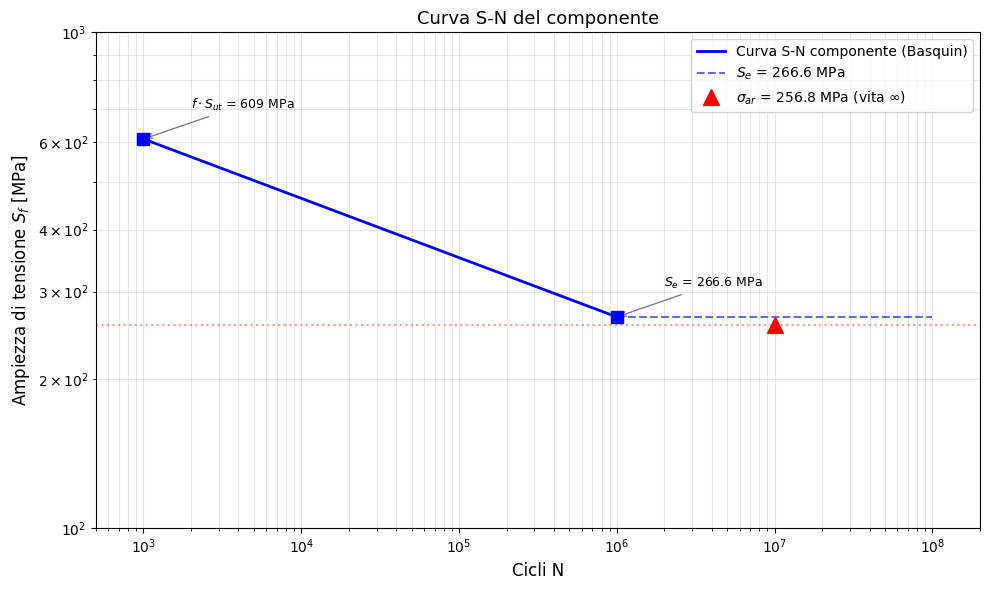

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

# Curva di Basquin: 10^3 → 10^6
N_range = np.logspace(3, 6, 500)
S_range = a_basq * N_range**b_basq

# Plateau oltre 10^6 (vita infinita per l'acciaio)
N_plateau = np.logspace(6, 8, 200)
S_plateau = np.full_like(N_plateau, S_e)

ax.loglog(N_range, S_range, 'b-', linewidth=2,
          label='Curva S-N componente (Basquin)')
ax.loglog(N_plateau, S_plateau, 'b--', linewidth=1.5, alpha=0.6,
          label=f'$S_e$ = {S_e:.1f} MPa')

# Punti di ancoraggio
ax.plot(1e3, fSut, 'bs', markersize=8, zorder=5)
ax.plot(1e6, S_e, 'bs', markersize=8, zorder=5)

# Punto operativo
if np.isinf(N_f):
    ax.plot(1e7, sigma_ar, 'r^', markersize=12, zorder=5,
            label=f'$\\sigma_{{ar}}$ = {sigma_ar:.1f} MPa (vita ∞)')
    ax.axhline(y=sigma_ar, color='r', linestyle=':', alpha=0.4)
else:
    ax.plot(N_f, sigma_ar, 'r^', markersize=12, zorder=5,
            label=f'$\\sigma_{{ar}}$ = {sigma_ar:.1f} MPa → $N_f$ = {N_f:,.0f}')
    ax.plot([N_f, N_f], [100, sigma_ar], 'r:', alpha=0.4)
    ax.axhline(y=sigma_ar, color='r', linestyle=':', alpha=0.4)

# Annotazioni
ax.annotate(f'$f \\cdot S_{{ut}}$ = {fSut:.0f} MPa',
            xy=(1e3, fSut), xytext=(2e3, fSut * 1.15),
            fontsize=9, ha='left',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate(f'$S_e$ = {S_e:.1f} MPa',
            xy=(1e6, S_e), xytext=(2e6, S_e * 1.15),
            fontsize=9, ha='left',
            arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Cicli N', fontsize=12)
ax.set_ylabel('Ampiezza di tensione $S_f$ [MPa]', fontsize=12)
ax.set_title('Curva S-N del componente', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(5e2, 2e8)
ax.set_ylim(100, 1000)
plt.tight_layout()
plt.show()

## Effetto dell'affidabilità — confronto 50% vs 90%

Il caso di riferimento con $k_e = 1.0$ (affidabilità 50\%) dà vita infinita con margine minimo. Con $k_e = 0.897$ (90\%) la situazione si inverte: $\sigma_{ar} > S_e$ e la vita diventa finita.

Questa cella riesegue la catena per entrambi i livelli di affidabilità e sovrappone le due curve S-N.

In [8]:
def compute_chain(D, h, t, F, S_ut, a_M, b_M, k_c, k_e):
    """Catena completa a 10 nodi. Restituisce dizionario dei risultati."""
    d = D - 2 * h
    sigma_nom = F / (t * d)

    ratio = 2 * h / D
    K_t = 3.065 - 3.370*ratio + 0.647*ratio**2 + 0.658*ratio**3
    sigma_max = K_t * sigma_nom

    S_e_prime = 0.55 * S_ut if S_ut < 1400 else 700.0
    k_a = a_M * S_ut**b_M
    marin = k_a * 1.0 * k_c * 1.0 * k_e
    S_e = marin * S_e_prime

    f = 1.06 - 4.1e-4 * S_ut + 1.5e-7 * S_ut**2
    fSut = f * S_ut
    a_b = fSut**2 / S_e
    b_b = -(1/3) * np.log10(fSut / S_e)

    sigma_a = sigma_max / 2
    sigma_m = sigma_max / 2
    sigma_ar = sigma_a / (1 - sigma_m / S_ut)

    N_f = np.inf if sigma_ar <= S_e else (sigma_ar / a_b)**(1 / b_b)

    return dict(sigma_nom=sigma_nom, K_t=K_t, sigma_max=sigma_max,
                S_e_prime=S_e_prime, k_a=k_a, marin=marin, S_e=S_e,
                f=f, fSut=fSut, a_basq=a_b, b_basq=b_b,
                sigma_ar=sigma_ar, N_f=N_f)

# Esecuzione per i due livelli di affidabilità
res_50 = compute_chain(D, h, t, F, S_ut, a_M, b_M, k_c, 1.000)
res_90 = compute_chain(D, h, t, F, S_ut, a_M, b_M, k_c, 0.897)

# Tabella riassuntiva
print(f"{'Parametro':<12} {'50%':>12} {'90%':>12}")
print("-" * 38)
for key in ['S_e', 'a_basq', 'b_basq', 'sigma_ar', 'N_f']:
    v50 = res_50[key]
    v90 = res_90[key]
    if key == 'N_f':
        s50 = '∞' if np.isinf(v50) else f'{v50:,.0f}'
        s90 = '∞' if np.isinf(v90) else f'{v90:,.0f}'
        print(f"{'Nf [cicli]':<12} {s50:>12} {s90:>12}")
    elif key == 'b_basq':
        print(f"{'b':<12} {v50:>12.3f} {v90:>12.3f}")
    elif key == 'a_basq':
        print(f"{'a [MPa]':<12} {v50:>12.0f} {v90:>12.0f}")
    else:
        label = key.replace('_', ' ')
        print(f"{label:<12} {v50:>12.1f} {v90:>12.1f}")

Parametro             50%          90%
--------------------------------------
S e                 266.6        239.1
a [MPa]              1393         1553
b                  -0.120       -0.135
sigma ar            256.8        256.8
Nf [cicli]              ∞      591,467


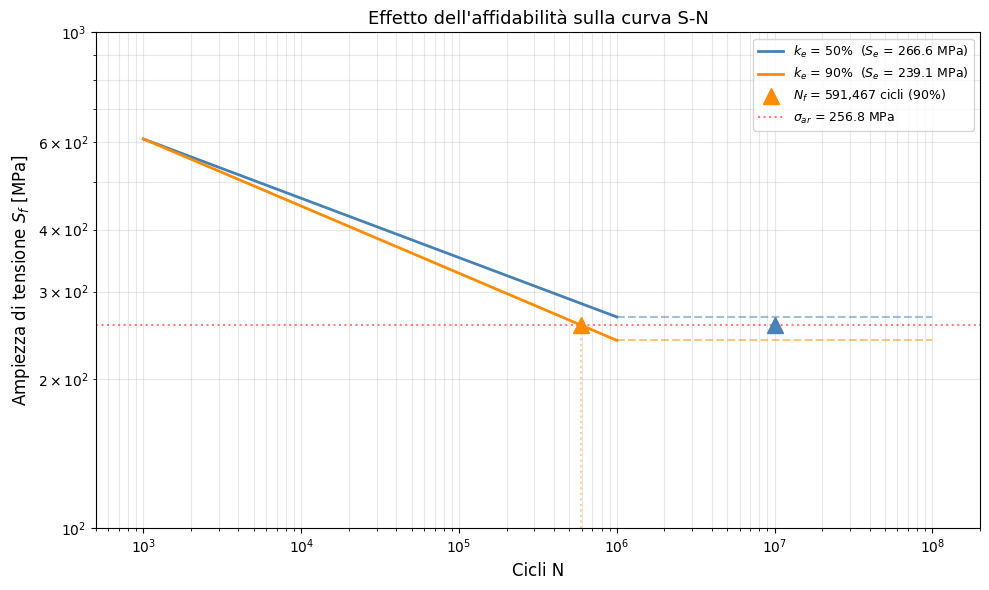

In [9]:
# Grafico confronto
fig, ax = plt.subplots(figsize=(10, 6))
N_range = np.logspace(3, 6, 500)

for res, ke_label, color, ls in [(res_50, '50%', 'steelblue', '-'),
                                  (res_90, '90%', 'darkorange', '-')]:
    S_range = res['a_basq'] * N_range**res['b_basq']
    N_plat  = np.logspace(6, 8, 200)
    S_plat  = np.full_like(N_plat, res['S_e'])

    ax.loglog(N_range, S_range, color=color, ls=ls, lw=2,
              label=f'$k_e$ = {ke_label}  ($S_e$ = {res["S_e"]:.1f} MPa)')
    ax.loglog(N_plat, S_plat, color=color, ls='--', lw=1.5, alpha=0.5)

    # Punto operativo
    if np.isinf(res['N_f']):
        ax.plot(1e7, res['sigma_ar'], '^', color=color, ms=11, zorder=5)
    else:
        ax.plot(res['N_f'], res['sigma_ar'], '^', color=color, ms=11, zorder=5,
                label=f'$N_f$ = {res["N_f"]:,.0f} cicli ({ke_label})')
        ax.plot([res['N_f'], res['N_f']], [100, res['sigma_ar']],
                ':', color=color, alpha=0.4)

# Linea σ_ar comune
ax.axhline(y=res_50['sigma_ar'], color='red', ls=':', alpha=0.5,
           label=f'$\\sigma_{{ar}}$ = {res_50["sigma_ar"]:.1f} MPa')

ax.set_xlabel('Cicli N', fontsize=12)
ax.set_ylabel('Ampiezza di tensione $S_f$ [MPa]', fontsize=12)
ax.set_title('Effetto dell\'affidabilità sulla curva S-N', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(5e2, 2e8)
ax.set_ylim(100, 1000)
plt.tight_layout()
plt.show()

## Nota — estensioni possibili

Questo notebook copre il calcolo su un **singolo punto** (la punta dell'intaglio). Per estendere l'analisi a fatica all'intero campo di tensione restituito dal FEM — valutando ogni nodo della mesh — il riferimento è [**pyLife**](https://github.com/boschresearch/pyLife) (Bosch Research): libreria open source che integra curve di Wöhler, correzione tensione media, e post-processing di risultati FEM in formato standard.

Il workflow sarebbe: CalculiX → file `.frd` → pyLife → mappa $N_f$ su tutto il componente.